# 📊 Análise de Sentimento com NLP

Este projeto aplica técnicas de **Processamento de Linguagem Natural (NLP)** para classificar textos como **sentimentos positivos ou negativos**.

O objetivo é construir um pipeline completo de Machine Learning incluindo:

- Limpeza e preparação de dados
- Vetorização de texto
- Treinamento de múltiplos modelos
- Otimização de hiperparâmetros
- Avaliação de desempenho
- Interpretação do modelo

Este projeto demonstra um fluxo completo de **Machine Learning aplicado a dados textuais**.

## Importação das bibliotecas

Nesta etapa carregamos todas as bibliotecas necessárias para:

- Manipulação de dados
- Processamento de texto
- Treinamento de modelos
- Avaliação de performance
- Visualização de resultados

In [65]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

## Carregamento do Dataset

O dataset contém textos coletados de redes sociais e suas respectivas emoções.

Para simplificar o problema, agrupamos as emoções em duas classes:

- **Positive**
- **Negative**

In [66]:
df = pd.read_csv("../data/sentimentdataset.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [67]:
positive_keywords = [
    "positive","joy","excitement","contentment","gratitude","happy","hopeful",
    "awe","euphoria","admiration","adoration","affection","amusement","blessed",
    "calmness","celebration","compassion","confidence","delight","elation",
    "enthusiasm","gratified","inspiration","love","optimism","pride","relief",
    "serenity","wonder","accomplishment","appreciation"
]

negative_keywords = [
    "negative","anger","anxiety","despair","loneliness","grief","sad",
    "embarrassed","confusion","fear","frustration","disappointment",
    "bitterness","betrayal","boredom","guilt","hate","hopeless","hurt",
    "insecurity","jealousy","loss","melancholy","pain","regret",
    "rejection","stress","tension","worry","pressure","obstacle"
]

def map_sentiment(sentiment):
    sentiment = sentiment.lower()

    for word in positive_keywords:
        if word in sentiment:
            return "Positive"
    for word in negative_keywords:
        if word in sentiment:
            return "Negative"
            

df["Sentiment"] = df["Sentiment"].apply(map_sentiment)
df = df.dropna()

## Exploração inicial dos dados

Aqui analisamos:

- Quantidade de registros
- Colunas presentes
- Tipos de dados

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 409 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  409 non-null    int64  
 1   Unnamed: 0    409 non-null    int64  
 2   Text          409 non-null    object 
 3   Sentiment     409 non-null    object 
 4   Timestamp     409 non-null    object 
 5   User          409 non-null    object 
 6   Platform      409 non-null    object 
 7   Hashtags      409 non-null    object 
 8   Retweets      409 non-null    float64
 9   Likes         409 non-null    float64
 10  Country       409 non-null    object 
 11  Year          409 non-null    int64  
 12  Month         409 non-null    int64  
 13  Day           409 non-null    int64  
 14  Hour          409 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 51.1+ KB


In [69]:
df.shape

(409, 15)

## Distribuição das classes

Vamos verificar quantos exemplos existem para cada classe de sentimento.

Isso é importante para entender se o dataset está balanceado.

In [70]:
df["Sentiment"].value_counts()

Sentiment
Positive    293
Negative    116
Name: count, dtype: int64

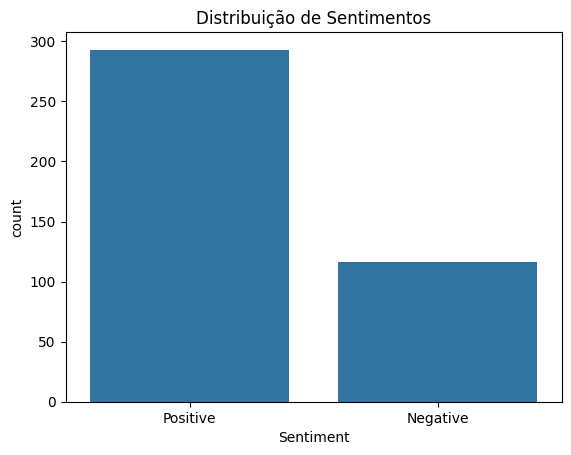

In [71]:
sns.countplot(x=df["Sentiment"])
plt.title("Distribuição de Sentimentos")
plt.show()

Text(0.5, 1.0, 'Distribuição do tamanho dos textos')

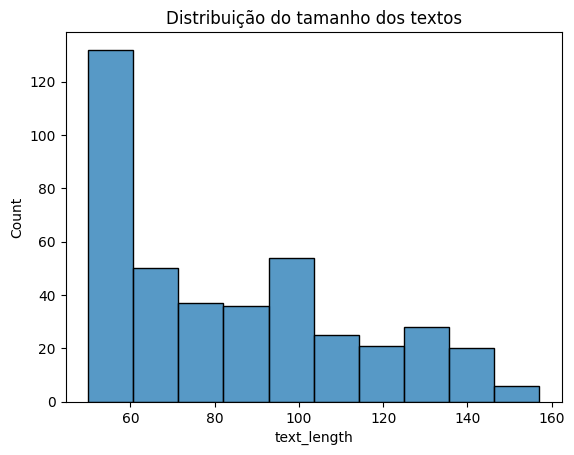

In [72]:
df["text_length"] = df["Text"].apply(len)

sns.histplot(df["text_length"])
plt.title("Distribuição do tamanho dos textos")

## Separação de variáveis

Dividimos o dataset em:

- **X** → textos
- **y** → sentimentos

In [73]:
X = df["Text"]
y = df["Sentiment"]

## Divisão entre treino e teste

Separaremos os dados em:

- **80% para treino**
- **20% para teste**

Isso permite avaliar o modelo em dados que ele nunca viu.

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Pipeline de processamento de texto

Utilizamos um pipeline contendo:

1️⃣ **TF-IDF Vectorizer**  

Transforma texto em números considerando:
- frequência da palavra no texto
- relevância da palavra no conjunto de documentos

Palavras muito comuns recebem menor peso, enquanto palavras mais informativas
recebem maior importância.

2️⃣ **Modelo de Machine Learning**

Isso garante que todo o processo seja reproduzível.

## Treinamento de múltiplos modelos

Testamos três algoritmos diferentes:

- Logistic Regression
- Naive Bayes
- Linear SVM

O objetivo é identificar qual apresenta melhor desempenho.

In [75]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english",ngram_range=(1,2),min_df=2)),
        ("classifier", model)
    ])
    
    pipeline.fit(X_train, y_train)
    
    preds = pipeline.predict(X_test)
    
    f1 = f1_score(y_test, preds, average="weighted")
    
    results[name] = f1
    
    print(f"{name} F1 Score: {f1:.4f}")

Logistic Regression F1 Score: 0.7920
Naive Bayes F1 Score: 0.8985
Linear SVM F1 Score: 0.9255


## Seleção do melhor modelo

Após treinar os modelos, selecionamos aquele com maior **F1 Score**, que equilibra precisão e recall.

In [76]:
best_model_name = max(results, key=results.get)

print("Melhor modelo:", best_model_name)

Melhor modelo: Linear SVM


## Otimização de hiperparâmetros

Utilizamos **GridSearchCV** para encontrar os melhores parâmetros para o modelo escolhido.

In [77]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LinearSVC())
])

param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_weighted"
)

grid.fit(X_train, y_train)

print("Melhor parâmetro:", grid.best_params_)
print("Melhor F1:", grid.best_score_)

Melhor parâmetro: {'classifier__C': 10}
Melhor F1: 0.8877366305001904


## Avaliação do modelo final

Agora avaliamos o modelo otimizado utilizando:

- Accuracy
- Precision
- Recall
- F1 Score

In [78]:
best_model = grid.best_estimator_

predictions = best_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions, average="weighted")
recall = recall_score(y_test, predictions, average="weighted")
f1 = f1_score(y_test, predictions, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9390243902439024
Precision: 0.9383214132893208
Recall: 0.9390243902439024
F1 Score: 0.9384865540963102


## Matriz de Confusão

A matriz de confusão permite visualizar:

- Acertos do modelo
- Erros de classificação

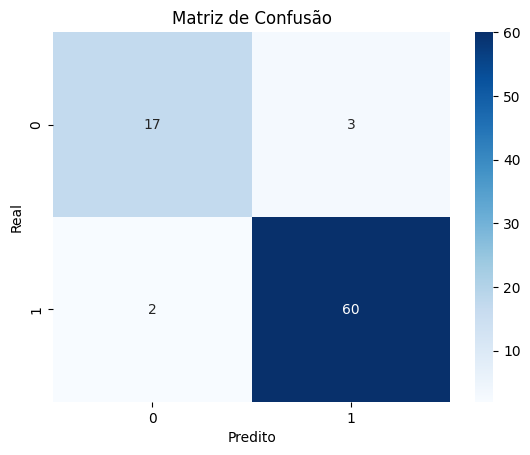

In [79]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

## Interpretação do modelo: palavras mais influentes

Após o treinamento do modelo, é possível analisar quais palavras tiveram maior influência na classificação de sentimentos.

Como o modelo utiliza **TF-IDF** para transformar o texto em vetores numéricos e um classificador linear **(Linear SVM)**, cada palavra recebe um **coeficiente** que indica sua contribuição para a decisão do modelo.

- **Coeficientes positivos** indicam palavras que contribuem para classificar um texto como **sentimento positivo**.

- **Coeficientes negativos** indicam palavras que contribuem para classificar um texto como **sentimento negativo**.

Nos gráficos abaixo são exibidas as **20 palavras mais importantes para cada classe**, permitindo compreender melhor como o modelo está tomando suas decisões.

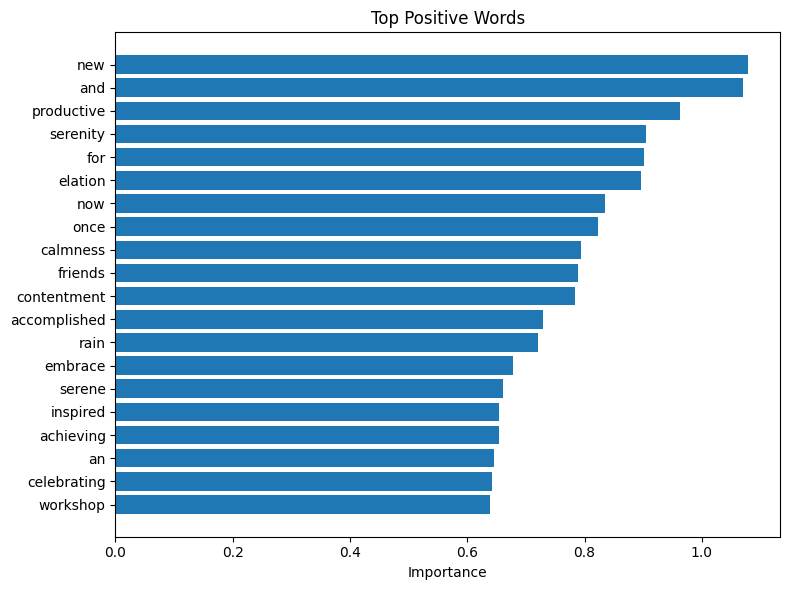

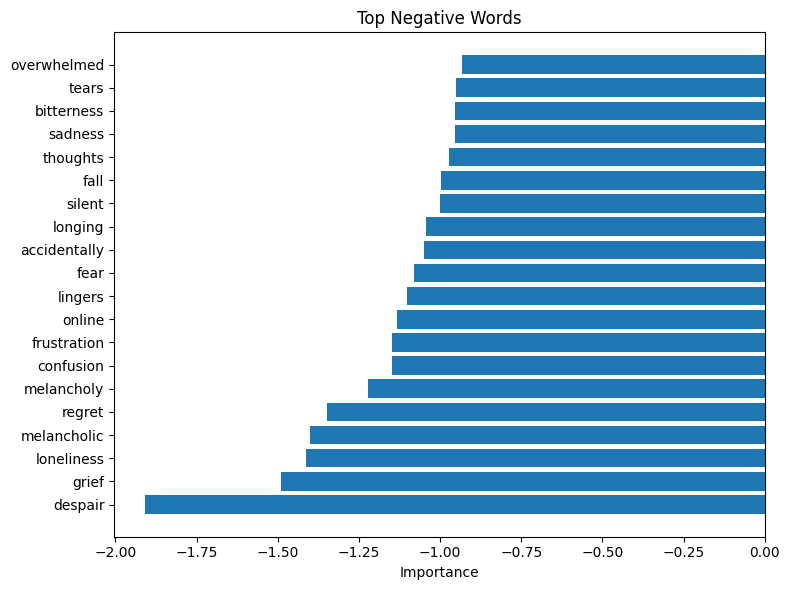

In [80]:
vectorizer = best_model.named_steps["tfidf"]
classifier = best_model.named_steps["classifier"]

feature_names = np.array(vectorizer.get_feature_names_out())
coefficients = classifier.coef_[0]

top_positive = np.argsort(coefficients)[-20:]
top_negative = np.argsort(coefficients)[:20]

positive_words = feature_names[top_positive]
positive_scores = coefficients[top_positive]

negative_words = feature_names[top_negative]
negative_scores = coefficients[top_negative]

plt.figure(figsize=(8,6))
plt.barh(positive_words, positive_scores)
plt.title("Top Positive Words")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
plt.barh(negative_words, negative_scores)
plt.title("Top Negative Words")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



Observa-se que palavras como new, and, productive possuem forte contribuição para classificações positivas, enquanto termos como despair, grief, loneliness contribuem para classificações negativas. Isso indica que o modelo está aprendendo padrões semânticos coerentes para distinguir os sentimentos.

## Teste com novas frases

Podemos testar o modelo com frases que não estavam no dataset.

In [81]:
texts = [
    "I love this day",
    "This is terrible",
    "Good weather today"
]

predicoes = best_model.predict(texts)

for x in range(0,3,1):
    print("A frase: " + texts[x] + ". Retorna o sentimento: " + predicoes[x])

A frase: I love this day. Retorna o sentimento: Positive
A frase: This is terrible. Retorna o sentimento: Negative
A frase: Good weather today. Retorna o sentimento: Positive


## Conclusão

Neste projeto desenvolvemos um pipeline completo de análise de sentimento utilizando técnicas de NLP.

Principais etapas realizadas:

- Preparação de dados
- Vetorização de texto com TF-IDF
- Treinamento de múltiplos modelos
- Otimização de hiperparâmetros
- Avaliação com métricas de classificação

O modelo final apresentou desempenho satisfatório considerando o tamanho reduzido do dataset.

Melhorias futuras incluem:

- Utilizar datasets maiores
- Aplicar modelos baseados em Transformers
- Implementar técnicas mais avançadas de pré-processamento